# Publication multi-panel figures

Panel labels, compact layouts, legends, colorbars, and mixed plot types.

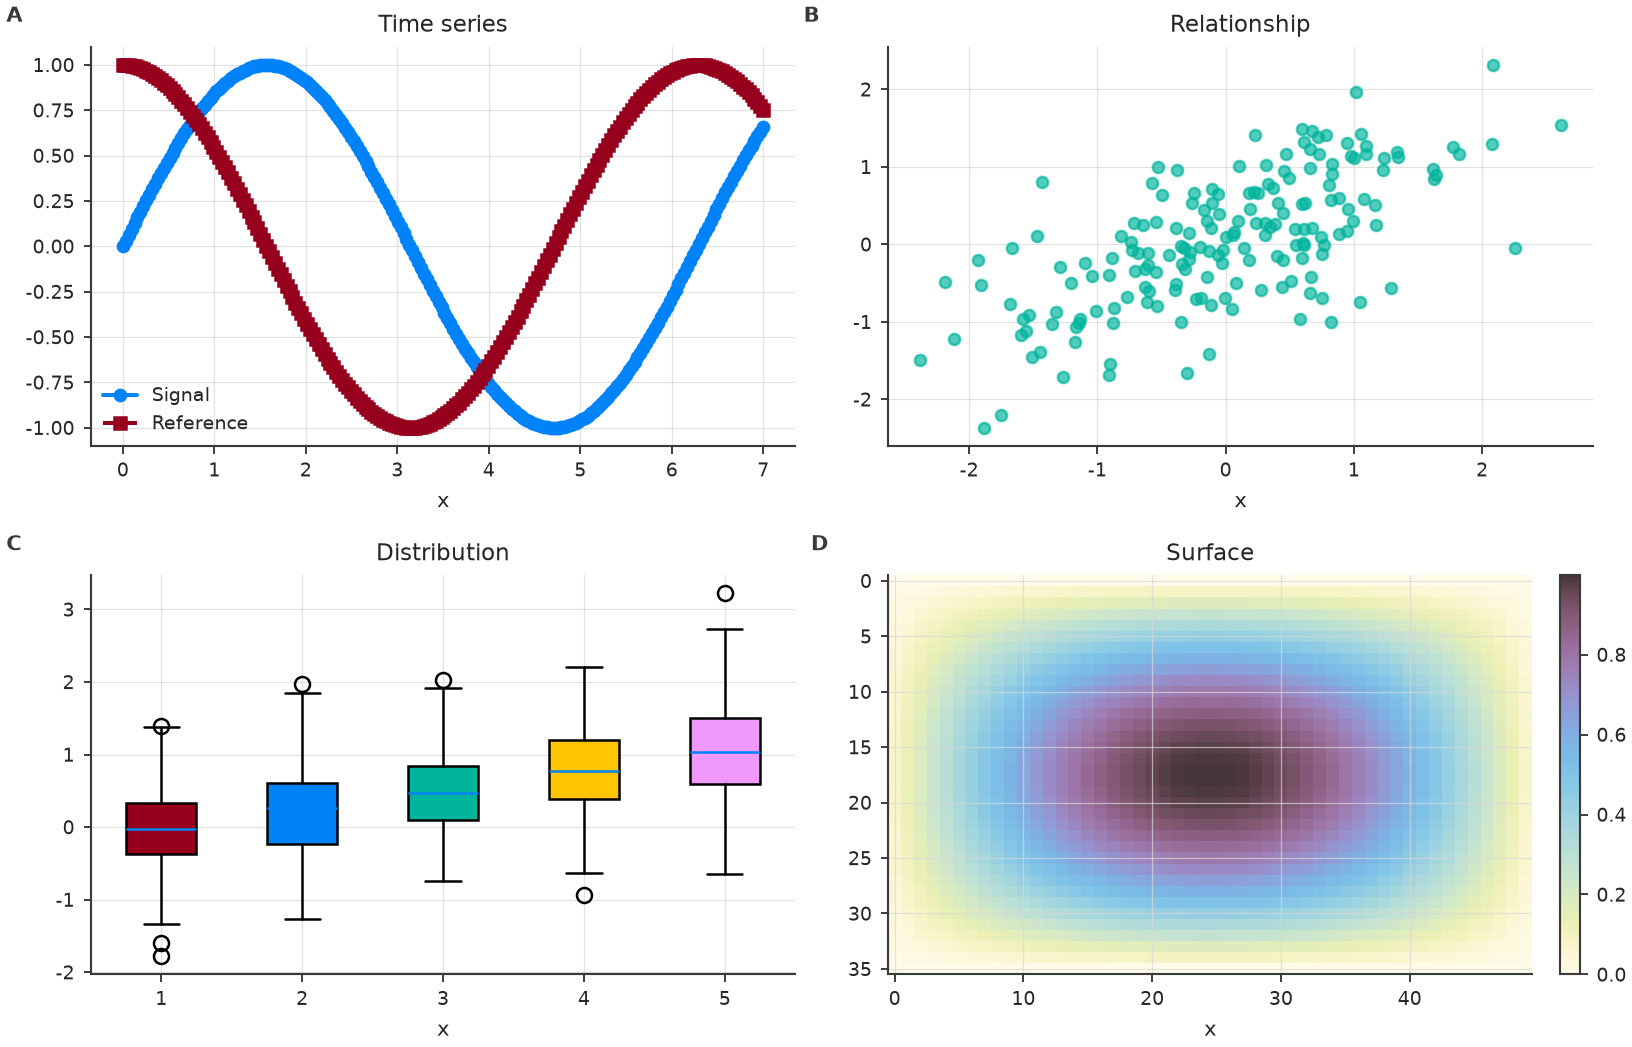

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contrastcolors as cc

cc.set_style("heri", font="DejaVu Sans")
rng=np.random.default_rng(12)
x=np.linspace(0,7,220)
fig,axes=plt.subplots(2,2,figsize=(9.2,6.0))

axes[0,0].plot(x,np.sin(x),color=cc.HERI_PALETTE[1],label="Signal")
axes[0,0].plot(x,np.cos(x),color=cc.HERI_PALETTE[0],linestyle="--",label="Reference")
axes[0,0].legend(); axes[0,0].set_title("Time series")

xx=rng.normal(size=180); yy=0.62*xx+rng.normal(scale=0.62,size=180)
axes[0,1].scatter(xx,yy,color=cc.HERI_PALETTE[2],alpha=0.68,s=20)
axes[0,1].set_title("Relationship")

groups=[rng.normal(i*0.25,0.6,160) for i in range(5)]
bp=axes[1,0].boxplot(groups,patch_artist=True)
for patch,color in zip(bp["boxes"],cc.HERI_PALETTE):
    patch.set_facecolor(color)
axes[1,0].set_title("Distribution")

z=np.outer(np.sin(np.linspace(0,np.pi,36)),np.cos(np.linspace(-1.5,1.5,50)))
im=axes[1,1].imshow(z,cmap=cc.HERI_CMAP,aspect="auto")
fig.colorbar(im,ax=axes[1,1],fraction=0.046,pad=0.04)
axes[1,1].set_title("Surface")

for label,ax in zip("ABCD",axes.flat):
    cc.panel_label(ax,label)
    ax.set_xlabel("x")
fig.tight_layout()

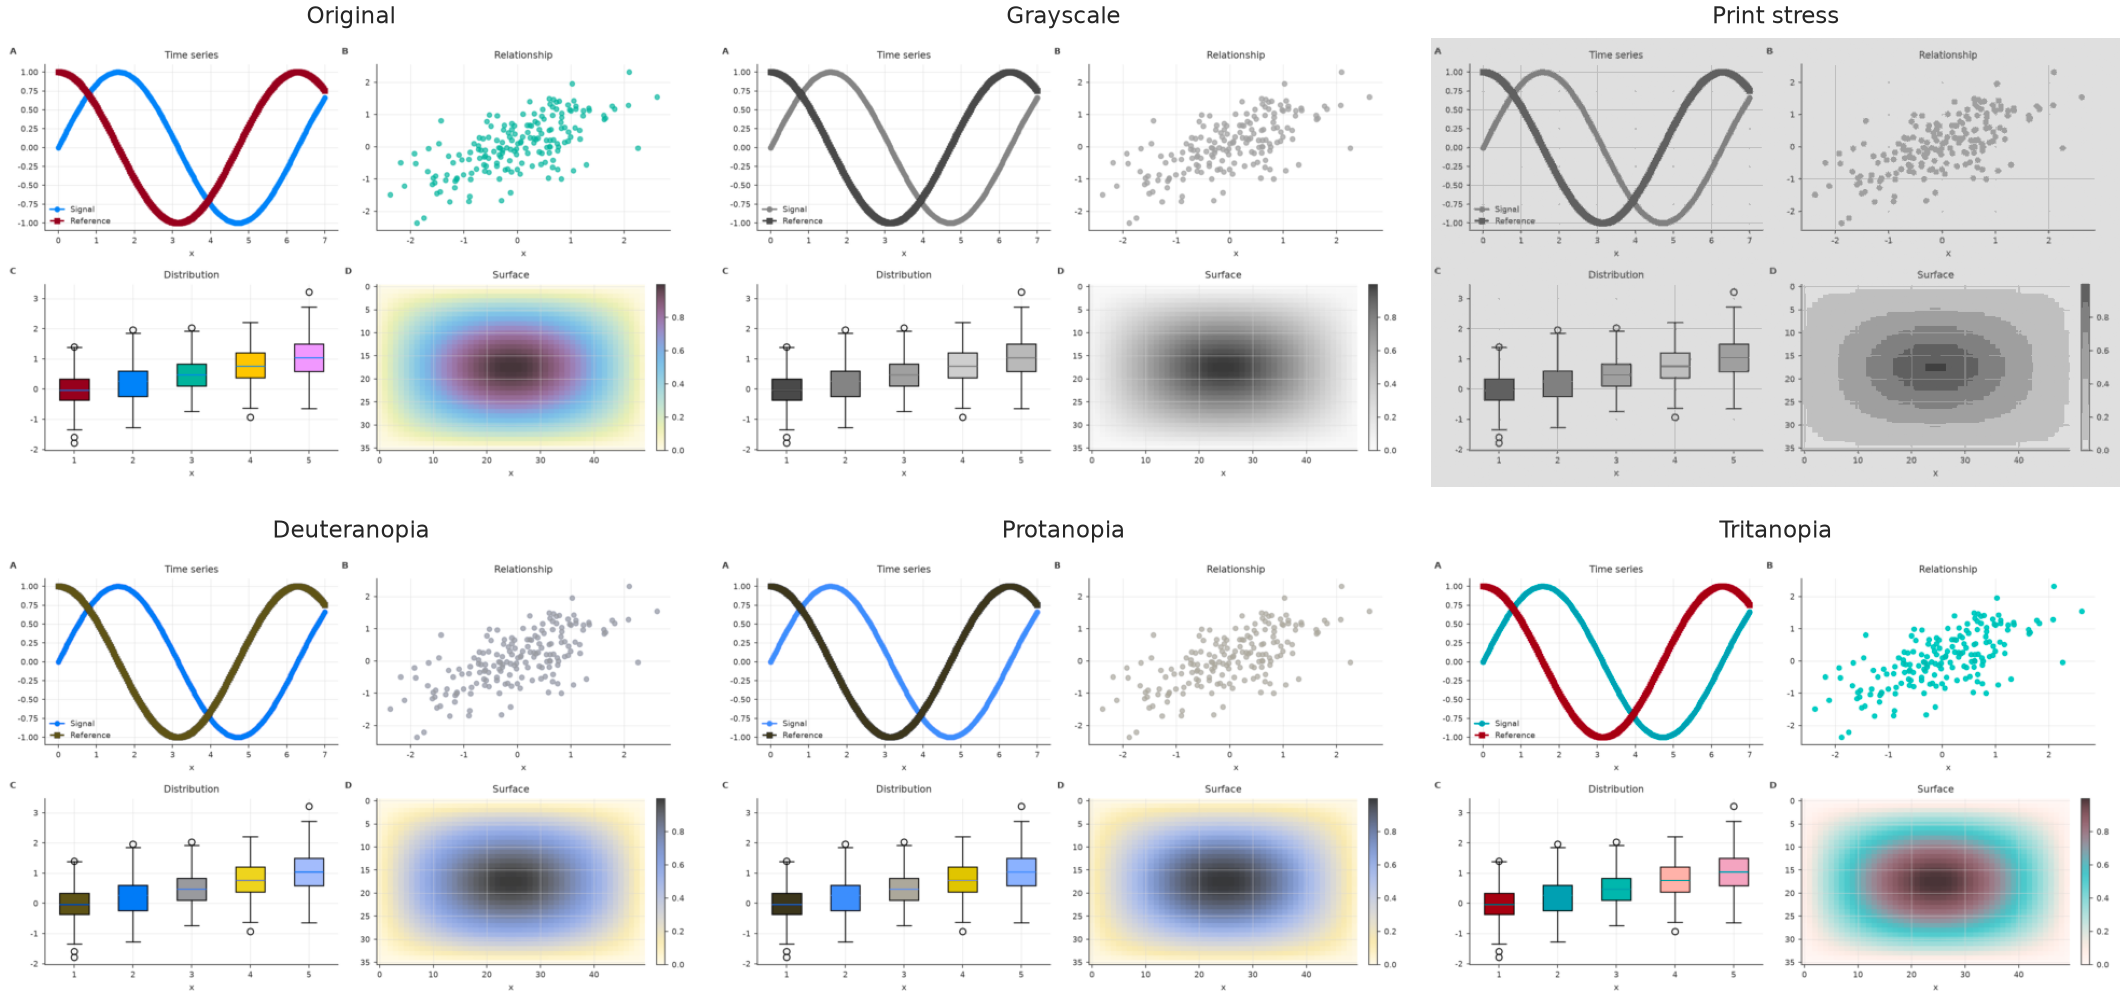

In [2]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()